# Flood–Road Network Intersection
## Greater Manchester — Scientifically Valid Link-Level Flood Exposure

### Methodology

The analysis answers: **which road links are physically inundated** at a given flood scenario?

**Key challenge — false positives from elevated infrastructure**
A naïve spatial intersection flags any link whose geometry overlaps the flood raster,
including bridges that pass *over* flooded ground.  We address this with two
complementary filters applied in order:

1. **OSM bridge / layer tag filter (primary)**
   Every link carries an `osmID`. We query the Overpass API in bulk for `bridge=yes`
   or `layer ≥ 1` on those ways. Links matching either condition are excluded.

2. **Flood-depth profile heuristic (secondary / fallback)**
   We sample the flood raster at 5 m intervals along each link. A genuine at-grade
   flooded link shows consistently non-zero depth along most of its length. A link
   where fewer than 20 % of sampled points are wet despite a non-zero maximum is
   quarantined as a suspected bridge for manual review.

**Flood severity thresholds — Defra FD2320 / HR Wallingford**

| Class          | Max depth (m) | Interpretation                   |
|----------------|---------------|----------------------------------|
| Dry            | < 0.10        | Passable                         |
| Shallow        | 0.10 – 0.30   | Hazardous for pedestrians        |
| Moderate       | 0.30 – 0.60   | Impassable for cars              |
| Deep           | > 0.60        | Dangerous for all modes          |

**Note on elevation data**
The GeoPackage `links` layer contains no Z coordinates and no absolute elevation
attribute. The `gradient` column gives relative slope per link but cannot identify
whether a link is elevated above the flood surface. Bridge detection therefore relies
on OSM tags (primary) and the depth-profile heuristic (secondary).

In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.sample
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import requests
import time
from shapely.geometry import box

print("Libraries loaded.")

Libraries loaded.


## 1. Configuration

In [17]:
TIF_PATH   = r"D:\Downloads\Manchester_2050_FloodMaps\R1C1_Flood_TIF\R1_C1_T39_390min.tif"
GPKG_PATH  = r"C:\Users\saadi\Documents\Cambridge\jibe\network\manchester_v3.13_2way.gpkg"
LAYER      = "links"

# Flood depth thresholds (metres) — Defra FD2320 / HR Wallingford
DEPTH_SHALLOW  = 0.10   # hazardous for pedestrians
DEPTH_MODERATE = 0.30   # impassable for cars
DEPTH_DEEP     = 0.60   # dangerous for all modes

SAMPLE_INTERVAL_M = 5   # sample raster every N metres along each link

# Heuristic bridge filter: links with fewer than this fraction of wet points
# are suspected bridges and excluded
HEURISTIC_WET_FRACTION = 0.20

## 2. Load data

In [18]:
links = gpd.read_file(GPKG_PATH, layer=LAYER)
print(f"Links loaded: {len(links):,}  |  CRS: {links.crs}")

with rasterio.open(TIF_PATH) as src:
    flood_crs    = src.crs
    flood_bounds = src.bounds
    flood_shape  = (src.height, src.width)
    flood_dtype  = src.dtypes[0]

print(f"Raster CRS: {flood_crs}  |  shape: {flood_shape}  |  dtype: {flood_dtype}")
print(f"Raster bounds: {flood_bounds}")

Links loaded: 1,053,665  |  CRS: EPSG:27700
Raster CRS: EPSG:27700  |  shape: (3409, 5491)  |  dtype: float32
Raster bounds: BoundingBox(left=370412.5, bottom=393657.5, right=397867.5, top=410702.5)


## 3. Align CRS and clip to raster extent

In [19]:
# Confirm both datasets share EPSG:27700 (British National Grid)
assert links.crs.to_epsg() == 27700, f"Unexpected network CRS: {links.crs}"
assert flood_crs.to_epsg() == 27700, f"Unexpected raster CRS: {flood_crs}"

# Restrict to links that intersect the flood tile's bounding box
raster_bbox  = box(*flood_bounds)
links_clip   = links[links.intersects(raster_bbox)].copy().reset_index(drop=True)
print(f"Links within flood tile: {len(links_clip):,}  (of {len(links):,} total)")

Links within flood tile: 348,923  (of 1,053,665 total)


## 4. Sample flood depth along each link

We interpolate points every `SAMPLE_INTERVAL_M` metres along each link geometry
(sub-pixel precision, independent of raster resolution) and sample the flood raster
at those exact coordinates.

**Performance:** all interpolated coordinates across every link are collected into a
single array first, then passed to `rasterio.sample()` in **one call**. This avoids
the per-link I/O overhead of the naïve approach while preserving full sub-pixel
accuracy — unlike raster-cell rasterisation methods which attribute whole pixels to a
link even when the geometry only clips a corner.

In [20]:
def build_sample_coords(geometries, interval=SAMPLE_INTERVAL_M):
    """
    Interpolate points every `interval` metres along each geometry and collect
    all coordinates into one flat list.

    Returns
    -------
    all_coords : list of (x, y) tuples  — all sample points across all links
    slices     : list of slice objects  — index range in all_coords for each link
    """
    all_coords = []
    slices     = []
    for geom in geometries:
        length = geom.length
        n_pts  = max(2, int(np.ceil(length / interval)) + 1)
        dists  = np.linspace(0, length, n_pts)
        pts    = [(geom.interpolate(d).x, geom.interpolate(d).y) for d in dists]
        start  = len(all_coords)
        all_coords.extend(pts)
        slices.append(slice(start, len(all_coords)))
    return all_coords, slices


print("Building interpolated sample coordinates …")
all_coords, slices = build_sample_coords(links_clip.geometry)
print(f"  Total sample points across all links: {len(all_coords):,}")

# Single rasterio.sample() call for all coordinates at once
print("Sampling flood raster (single batched call) …")
with rasterio.open(TIF_PATH) as src:
    all_vals = np.array([v[0] for v in src.sample(all_coords)], dtype=np.float32)
all_vals[all_vals < 0] = 0   # clamp artefact negatives

# Reconstruct per-link statistics from the flat array
def link_stats(s):
    vals = all_vals[s]
    return vals, float(vals.max()), float(vals.mean()), float(np.mean(vals >= DEPTH_SHALLOW))

results = [link_stats(s) for s in slices]
links_clip["flood_samples"] = [r[0] for r in results]
links_clip["flood_max_m"]   = [r[1] for r in results]
links_clip["flood_mean_m"]  = [r[2] for r in results]
links_clip["flood_pct_wet"] = [r[3] for r in results]

n_wet = (links_clip.flood_max_m >= DEPTH_SHALLOW).sum()
print(f"Sampling complete.")
print(f"  Links with max depth >= {DEPTH_SHALLOW} m: {n_wet:,}")

Building interpolated sample coordinates …
  Total sample points across all links: 3,997,082
Sampling flood raster (single batched call) …
Sampling complete.
  Links with max depth >= 0.1 m: 22,191


## 5. Bridge detection — OSM tag query (primary filter)

We query the [Overpass API](https://overpass-api.de) for `bridge=yes` or `layer >= 1`
on the OSM way IDs of all candidate (potentially flooded) links.  Requests are batched
to 500 IDs each to stay within Overpass limits.

In [21]:
OVERPASS_URL = "https://overpass-api.de/api/interpreter"
BATCH_SIZE   = 500   # IDs per Overpass request
RETRY_PAUSE  = 10    # seconds to wait on HTTP 429

def query_bridge_tags(osm_ids: list) -> set:
    """
    Query Overpass for ways with bridge=yes or layer>=1.
    Returns the set of elevated OSM way IDs.
    """
    id_str = ",".join(str(i) for i in osm_ids)
    query  = f"[out:json][timeout:60];way(id:{id_str});out tags;"
    for attempt in range(3):
        try:
            r = requests.post(OVERPASS_URL, data={"data": query}, timeout=90)
            if r.status_code == 429:
                print(f"  Rate limited — waiting {RETRY_PAUSE} s …")
                time.sleep(RETRY_PAUSE)
                continue
            r.raise_for_status()
            elevated = set()
            for element in r.json()["elements"]:
                tags   = element.get("tags", {})
                bridge = tags.get("bridge", "no")
                layer  = int(tags.get("layer", 0))
                if bridge not in ("no", "") or layer >= 1:
                    elevated.add(element["id"])
            return elevated
        except Exception as e:
            print(f"  Attempt {attempt + 1} failed: {e}")
            time.sleep(5)
    print("  All attempts failed — returning empty set.")
    return set()

# Only query IDs of links that are potentially flooded (max depth >= shallow threshold)
candidate_ids = (
    links_clip
    .loc[links_clip.flood_max_m >= DEPTH_SHALLOW, "osmID"]
    .dropna().astype(int).unique().tolist()
)
print(f"Querying Overpass for {len(candidate_ids):,} OSM way IDs in batches of {BATCH_SIZE} …")

elevated_osm_ids = set()
for i in range(0, len(candidate_ids), BATCH_SIZE):
    batch  = candidate_ids[i : i + BATCH_SIZE]
    result = query_bridge_tags(batch)
    elevated_osm_ids.update(result)
    print(f"  Batch {i // BATCH_SIZE + 1}/{-(-len(candidate_ids)//BATCH_SIZE)}: "
          f"{len(result)} elevated ways")
    time.sleep(1)   # polite delay

print(f"Total elevated OSM ways: {len(elevated_osm_ids):,}")

Querying Overpass for 7,923 OSM way IDs in batches of 500 …
  Attempt 1 failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
  Attempt 2 failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
  Attempt 3 failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
  All attempts failed — returning empty set.
  Batch 1/16: 0 elevated ways
  Attempt 1 failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
  Attempt 2 failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
  Attempt 3 failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
  All attempts failed — returning empty set.
  Batch 2/16: 0 elevated ways
  Attempt 1 failed: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
  Attempt 2 failed: 406 Client Error: Not Acceptable for url: https://overpa

## 6. Bridge detection — depth-profile heuristic (secondary filter)

A genuine at-grade flooded link shows flood depth > 0 along the majority of its length.
A bridge crossing a flood plain may register a non-zero *maximum* depth (because the
surrounding ground under or beside the bridge is wet) while the road deck itself is dry.

**Heuristic rule**: if fewer than `HEURISTIC_WET_FRACTION` (20 %) of sampled points
along a link exceed the shallow threshold, the link is flagged as a suspected bridge
and excluded alongside confirmed OSM bridges.

In [22]:
candidate_mask = links_clip.flood_max_m >= DEPTH_SHALLOW

heuristic_bridge_mask = (
    candidate_mask &
    (links_clip.flood_pct_wet < HEURISTIC_WET_FRACTION)
)
links_clip["heuristic_bridge"] = heuristic_bridge_mask

print(f"Links flagged as suspected bridge by depth-profile heuristic: "
      f"{heuristic_bridge_mask.sum():,}")

Links flagged as suspected bridge by depth-profile heuristic: 7,234


## 7. Classify flooded links

In [23]:
links_clip["osm_bridge"] = links_clip["osmID"].astype("Int64").isin(elevated_osm_ids)
links_clip["is_bridge"]  = links_clip["osm_bridge"] | links_clip["heuristic_bridge"]

def classify(row):
    if row["is_bridge"]:
        return "bridge / elevated"
    d = row["flood_max_m"]
    if d < DEPTH_SHALLOW:
        return "dry"
    elif d < DEPTH_MODERATE:
        return "shallow (>=0.1 m)"
    elif d < DEPTH_DEEP:
        return "moderate (>=0.3 m)"
    else:
        return "deep (>=0.6 m)"

links_clip["flood_class"] = links_clip.apply(classify, axis=1)

print(links_clip["flood_class"].value_counts().to_string())

flood_class
dry                   326732
shallow (>=0.1 m)      10721
bridge / elevated       7234
moderate (>=0.3 m)      2875
deep (>=0.6 m)          1361


## 8. Visualise

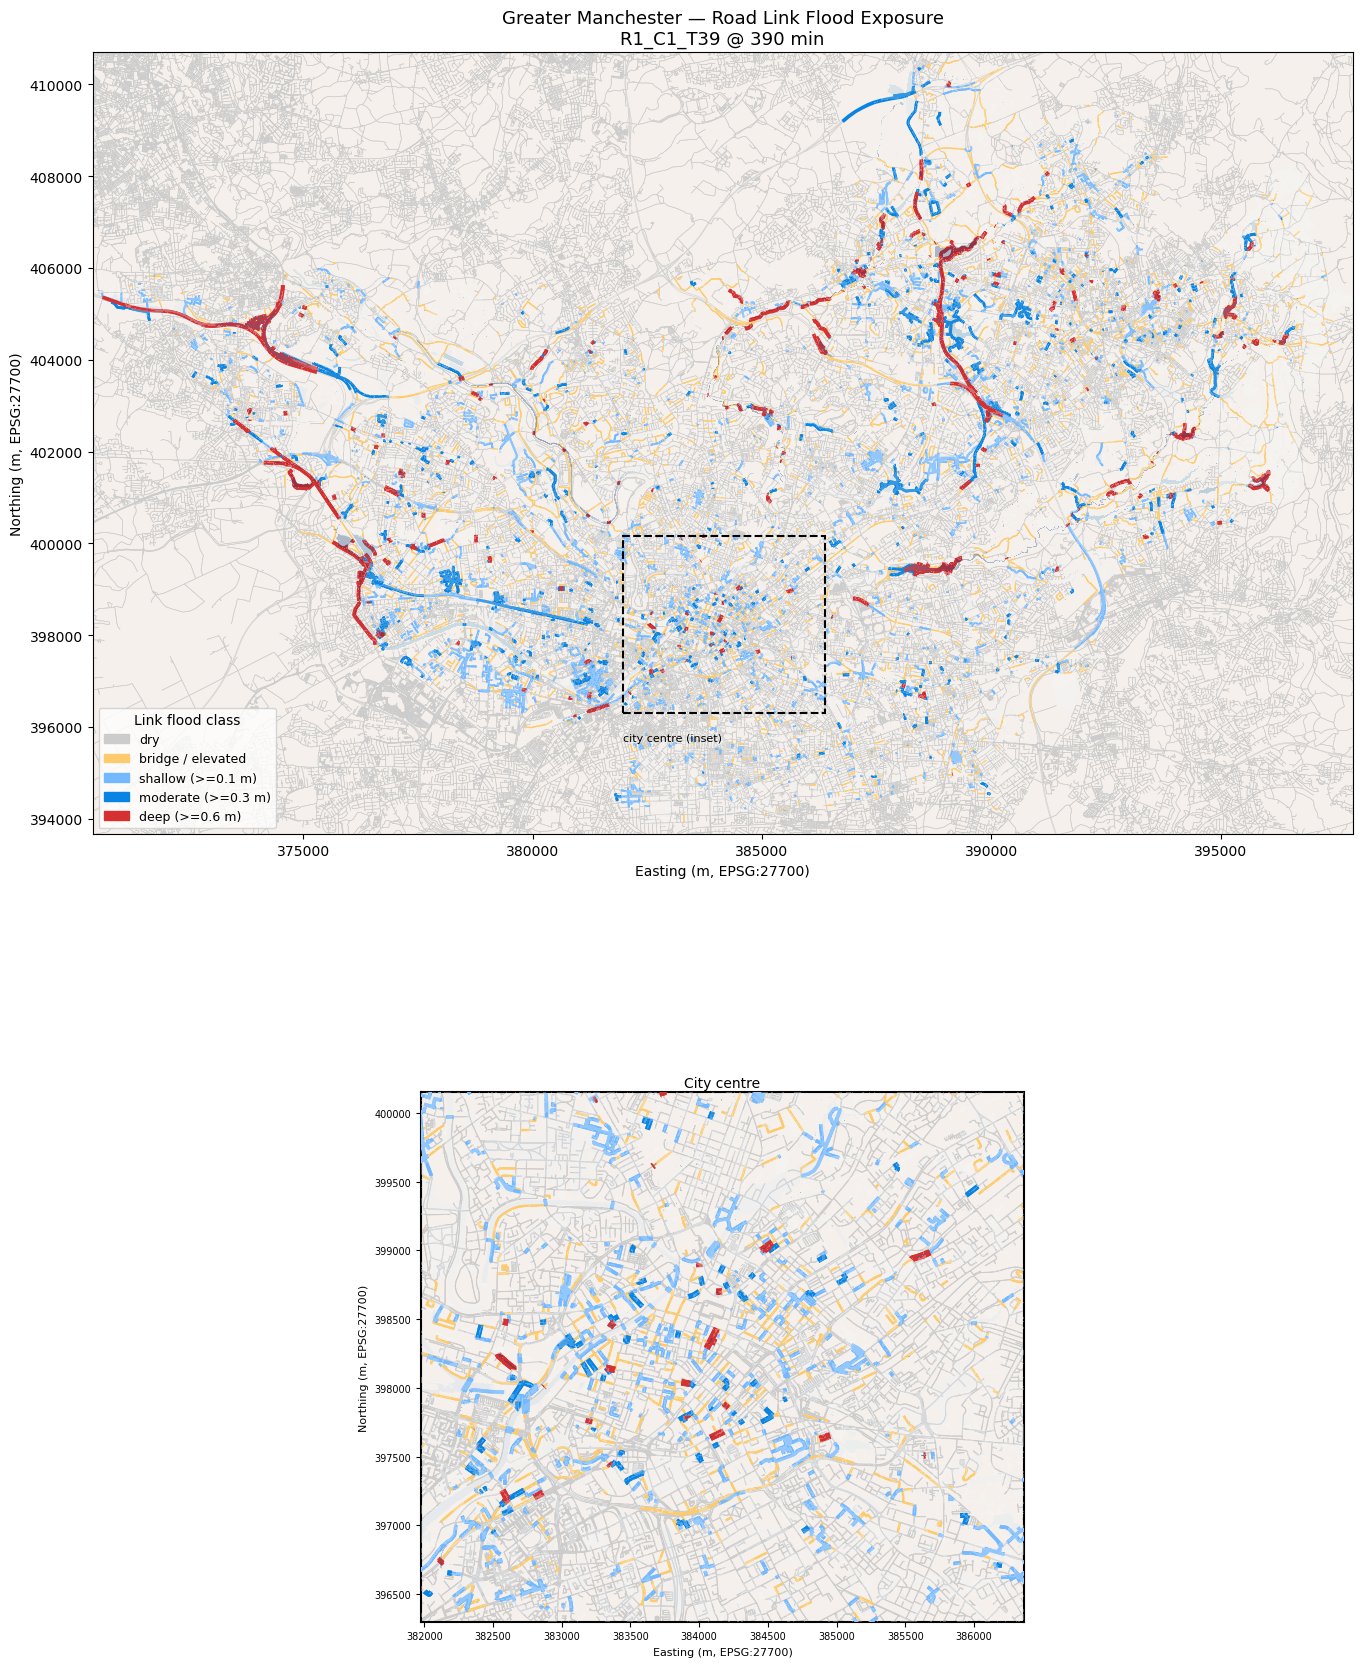

Saved: flood_road_exposure.png


In [24]:
import matplotlib.patches as mpatches

CLASS_STYLE = {
    "dry":                  {"color": "#cccccc", "lw": 0.4, "zorder": 1},
    "bridge / elevated":    {"color": "#fdcb6e", "lw": 0.9, "zorder": 2},
    "shallow (>=0.1 m)":    {"color": "#74b9ff", "lw": 1.4, "zorder": 3},
    "moderate (>=0.3 m)":   {"color": "#0984e3", "lw": 2.0, "zorder": 4},
    "deep (>=0.6 m)":       {"color": "#d63031", "lw": 2.6, "zorder": 5},
}

# City centre bounding box (EPSG:27700, metres)
CC = dict(xmin=381977, xmax=386363, ymin=396298, ymax=400151)

# ── Flood raster (loaded once, shared by both axes) ──────────────────────
with rasterio.open(TIF_PATH) as src:
    flood_data = src.read(1).astype(np.float32)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
flood_data[flood_data <= 0] = np.nan
cmap_f     = plt.cm.Blues.copy()
cmap_f.set_bad(alpha=0)
flood_norm = mcolors.Normalize(vmin=0, vmax=np.nanpercentile(flood_data, 99))

def draw_layers(ax, lw_scale=1.0):
    """Plot classified road links and flood raster overlay onto `ax`."""
    for cls, style in CLASS_STYLE.items():
        subset = links_clip[links_clip["flood_class"] == cls]
        if len(subset):
            subset.plot(ax=ax, color=style["color"],
                        linewidth=style["lw"] * lw_scale,
                        zorder=style["zorder"])
    ax.imshow(flood_data, cmap=cmap_f, norm=flood_norm,
              extent=extent, origin="upper", alpha=0.30,
              zorder=6, interpolation="nearest")

# ── Figure layout: main map above, inset below centred at half figure width
FIG_W = 14          # total figure width (inches)
INSET_W = FIG_W / 2  # inset width = half figure width (square)

# Height: main map keeps ~11 in aspect, inset is square at INSET_W inches
fig = plt.figure(figsize=(FIG_W, 11 + INSET_W + 0.8))

# 4-column gridspec: inset occupies the middle 2 columns (= half width, centred)
gs = fig.add_gridspec(
    2, 4,
    height_ratios=[11, INSET_W],
    hspace=0.12,
    left=0.07, right=0.97, top=0.96, bottom=0.04
)
ax       = fig.add_subplot(gs[0, :])     # main map — full width
ax_inset = fig.add_subplot(gs[1, 1:3])  # inset    — centred, half width

# ── Main map ─────────────────────────────────────────────────────────────
ax.set_facecolor("#f5f0eb")
draw_layers(ax)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Dashed rectangle showing city-centre inset extent
rect = mpatches.Rectangle(
    (CC["xmin"], CC["ymin"]),
    CC["xmax"] - CC["xmin"], CC["ymax"] - CC["ymin"],
    linewidth=1.5, edgecolor="black", facecolor="none",
    linestyle="--", zorder=10
)
ax.add_patch(rect)
ax.text(CC["xmin"], CC["ymin"] - 600, "city centre (inset)",
        fontsize=8, color="black", zorder=11)

patches = [mpatches.Patch(color=s["color"], label=cls)
           for cls, s in CLASS_STYLE.items()]
ax.legend(handles=patches, title="Link flood class", fontsize=9, loc="lower left")
ax.set_title("Greater Manchester — Road Link Flood Exposure\nR1_C1_T39 @ 390 min",
             fontsize=13)
ax.set_xlabel("Easting (m, EPSG:27700)")
ax.set_ylabel("Northing (m, EPSG:27700)")
ax.ticklabel_format(style="plain")

# ── City-centre inset ────────────────────────────────────────────────────
ax_inset.set_facecolor("#f5f0eb")
draw_layers(ax_inset, lw_scale=1.8)   # slightly thicker lines at zoom level
ax_inset.set_xlim(CC["xmin"], CC["xmax"])
ax_inset.set_ylim(CC["ymin"], CC["ymax"])
ax_inset.set_aspect("equal")
ax_inset.set_title("City centre", fontsize=10, pad=4)
ax_inset.set_xlabel("Easting (m, EPSG:27700)", fontsize=8)
ax_inset.set_ylabel("Northing (m, EPSG:27700)", fontsize=8)
ax_inset.tick_params(labelsize=7)
ax_inset.ticklabel_format(style="plain")
for spine in ax_inset.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)

plt.savefig("flood_road_exposure.png", dpi=150)
plt.show()
print("Saved: flood_road_exposure.png")

## 9. Summary statistics

In [25]:
summary = (
    links_clip
    .groupby("flood_class")["length"]
    .agg(n_links="count", total_km=lambda x: x.sum() / 1000)
    .reset_index()
    .rename(columns={"total_km": "total_length_km"})
    .sort_values("total_length_km", ascending=False)
)
print(summary.to_string(index=False))

       flood_class  n_links  total_length_km
               dry   326732     15701.650541
 bridge / elevated     7234       803.865593
 shallow (>=0.1 m)    10721       540.300391
moderate (>=0.3 m)     2875       191.605904
    deep (>=0.6 m)     1361       127.285620


## 10. Export results

In [26]:
out_cols = ["edgeID", "osmID", "name", "linkID", "length",
            "flood_max_m", "flood_mean_m", "flood_pct_wet",
            "osm_bridge", "heuristic_bridge", "is_bridge",
            "flood_class", "geometry"]

# Flooded (non-bridge) links only
flooded = links_clip[
    links_clip["flood_class"].isin([
        "shallow (>=0.1 m)", "moderate (>=0.3 m)", "deep (>=0.6 m)"
    ])
]
flooded[out_cols].to_file("flooded_links.gpkg", driver="GPKG", layer="flooded_links")

# Full classified network
links_clip[out_cols].to_file(
    "all_links_flood_classified.gpkg", driver="GPKG", layer="links"
)

print(f"Flooded links exported: {len(flooded):,}  -> flooded_links.gpkg")
print(f"Full network exported:  {len(links_clip):,}  -> all_links_flood_classified.gpkg")

Flooded links exported: 14,957  -> flooded_links.gpkg
Full network exported:  348,923  -> all_links_flood_classified.gpkg


## 11. Process all flood time steps (0 – 540 min)

The flood event is represented by 55 GeoTIFF rasters at 10-minute intervals.
Each raster is sampled along the clipped road links using the same batched
`rasterio.sample()` approach from Section 4. Results are stored in a single
wide DataFrame (`ts_depth`) with one column per time step.

This is the computationally intensive step; the raster I/O is kept efficient
by opening each file once and issuing a single sample call per time step.

In [28]:
import re
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import rasterio.transform as rtransform
from tqdm.notebook import tqdm

TIF_DIR = Path(r"D:\Downloads\Manchester_2050_FloodMaps\R1C1_Flood_TIF")

def parse_minutes(path):
    m = re.search(r"_(\d+)min\.tif$", path.name)
    return int(m.group(1)) if m else -1

tif_files  = sorted(TIF_DIR.glob("*.tif"), key=parse_minutes)
tif_files  = [f for f in tif_files if parse_minutes(f) >= 0]
time_steps = [parse_minutes(f) for f in tif_files]
print(f"Time steps found: {len(tif_files)}  ({time_steps[0]} – {time_steps[-1]} min)")

# ── Step 1: interpolate sample coordinates ONCE ──────────────────────────
print("Building sample coordinates …", end=" ")
all_coords_ts, slices_ts = build_sample_coords(links_clip.geometry)
xs = np.array([c[0] for c in all_coords_ts], dtype=np.float64)
ys = np.array([c[1] for c in all_coords_ts], dtype=np.float64)
print(f"{len(xs):,} points across {len(slices_ts):,} links")

# ── Step 2: convert coordinates to pixel indices ONCE ───────────────────
print("Computing pixel indices …", end=" ")
with rasterio.open(tif_files[0]) as src:
    transform = src.transform
    H, W      = src.height, src.width
rows_idx, cols_idx = rtransform.rowcol(transform, xs, ys)
rows_idx = np.clip(rows_idx, 0, H - 1).astype(np.int32)
cols_idx = np.clip(cols_idx, 0, W - 1).astype(np.int32)
print("done")

# ── Step 3: reduceat start indices ───────────────────────────────────────
reduce_starts = np.array([s.start for s in slices_ts], dtype=np.int64)

# ── Step 4: parallel TIF reads with live progress bar ───────────────────
n_links    = len(links_clip)
max_depths = np.zeros((len(tif_files), n_links), dtype=np.float32)

def process_tif(args):
    i, path = args
    with rasterio.open(path) as src:
        data = src.read(1)
    vals = data[rows_idx, cols_idx].astype(np.float32)
    vals[vals < 0] = 0
    return i, np.maximum.reduceat(vals, reduce_starts)

N_WORKERS = min(8, len(tif_files))

# as_completed() updates the bar as each thread finishes rather than
# waiting for results in submission order
with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(process_tif, (i, p)): i
               for i, p in enumerate(tif_files)}
    with tqdm(total=len(futures), desc="Sampling rasters",
              unit="raster", ncols=80) as pbar:
        for future in as_completed(futures):
            i, link_maxes = future.result()
            max_depths[i] = link_maxes
            pbar.update(1)
            pbar.set_postfix({"last_t": f"{time_steps[i]} min"})

ts_depth = pd.DataFrame(
    max_depths.T,
    index=links_clip["linkID"],
    columns=time_steps,
)
print(f"Done.  ts_depth shape: {ts_depth.shape}  (links × time steps)")


Time steps found: 55  (0 – 540 min)
Building sample coordinates … 3,997,082 points across 348,923 links
Computing pixel indices … done


Sampling rasters:   0%|                              | 0/55 [00:00<?, ?raster/s]

Done.  ts_depth shape: (348923, 55)  (links × time steps)


## 12. Network capacity impact and resilience metrics

### Scientific basis

#### Speed–depth relationship
Vehicle speed under flooding is modelled using the empirical formula from
**Pregnolato et al. (2017)**:

> v(d) = 0.0009 d² − 0.5529 d + 86.9   [km/h],  d in mm

where *d* is flood depth (mm). The relationship was derived from experimental
flume data and field observations; it returns the maximum safe driving speed
at a given inundation depth.

**Reference:** Pregnolato M, Ford A, Wilkinson SM, Dawson RJ (2017).
*The impact of flooding on road transport: A depth-disruption function.*
Transportation Research Part D, 55, 67–81.
DOI: [10.1016/j.trd.2017.06.020](https://doi.org/10.1016/j.trd.2017.06.020)

#### Network vulnerability
The **capacity loss ratio** (CLR) quantifies the fraction of weighted network
capacity removed by flooding at each time step, following the operationalisation
of network vulnerability in **Berdica (2002)** and **Mattsson & Jenelius (2015)**:

> CLR(t) = Σᵢ [capacity_i × (1 − v_flood_i / v_orig_i)] / Σᵢ capacity_i

AADT is used as the capacity proxy for each link.

**References:**
- Berdica K (2002). *An introduction to road vulnerability.* Transport Policy, 9(2), 117–127.
  DOI: [10.1016/S0967-070X(01)00032-0](https://doi.org/10.1016/S0967-070X(01)00032-0)
- Mattsson L-G, Jenelius E (2015). *Vulnerability and resilience of transport systems.*
  Transportation Research Part D, 41, 454–466.
  DOI: [10.1016/j.trd.2015.06.011](https://doi.org/10.1016/j.trd.2015.06.011)

#### Resilience
The **resilience index (RI)** is derived from the resilience triangle of
**Bruneau et al. (2003)**:

> RI = 1 − [ ∫ (1 − Q(t)) dt ] / T_event

where Q(t) = 1 − CLR(t) is the network functionality and T_event is the
total event duration.  RI = 1 means no loss; RI = 0 means total loss throughout.

**Reference:** Bruneau M et al. (2003). *A framework to quantitatively assess and
enhance the seismic resilience of communities.* Earthquake Spectra, 19(4), 733–752.
DOI: [10.1193/1.1623497](https://doi.org/10.1193/1.1623497)

In [29]:
# ── Pregnolato speed–depth function ─────────────────────────────────────
def pregnolato_speed_ms(depth_m):
    """
    Return reduced vehicle freespeed (m/s) for a given flood depth (metres).
    Formula: v = 0.0009*d^2 - 0.5529*d + 86.9  (km/h), d in mm.
    Capped at 0 for depths where v < 0; returned in m/s.
    Reference: Pregnolato et al. (2017) DOI:10.1016/j.trd.2017.06.020
    """
    d_mm = depth_m * 1000
    v_kmh = 0.0009 * d_mm**2 - 0.5529 * d_mm + 86.9
    v_kmh = np.clip(v_kmh, 0, None)
    return v_kmh / 3.6   # km/h → m/s

# ── Per-link original freespeed and AADT ────────────────────────────────
orig_speed = links_clip.set_index("linkID")["freespeed"]   # m/s
aadt       = links_clip.set_index("linkID")["aadt"].fillna(0).clip(lower=0)

# Total weighted capacity (denominator for CLR)
total_capacity = aadt.sum()

# ── Time-series metrics ──────────────────────────────────────────────────
records = []
for t in time_steps:
    depths = ts_depth[t]                          # Series: linkID → max depth

    # Speed reduction per link
    reduced_speed = depths.apply(pregnolato_speed_ms)
    reduced_speed = reduced_speed.clip(upper=orig_speed)  # never exceed limit

    # Flood severity classification
    dry      = (depths <  DEPTH_SHALLOW)
    shallow  = (depths >= DEPTH_SHALLOW)  & (depths < DEPTH_MODERATE)
    moderate = (depths >= DEPTH_MODERATE) & (depths < DEPTH_DEEP)
    deep     = (depths >= DEPTH_DEEP)

    # Km affected per class
    length = links_clip.set_index("linkID")["length"] / 1000   # km

    # Capacity loss ratio
    speed_ratio   = (reduced_speed / orig_speed.reindex(reduced_speed.index)).fillna(1)
    capacity_loss = (aadt * (1 - speed_ratio)).sum() / total_capacity if total_capacity > 0 else 0

    records.append({
        "time_min":          t,
        "km_shallow":        length[shallow].sum(),
        "km_moderate":       length[moderate].sum(),
        "km_deep":           length[deep].sum(),
        "km_affected":       length[shallow | moderate | deep].sum(),
        "n_links_affected":  int((shallow | moderate | deep).sum()),
        "capacity_loss_ratio": capacity_loss,
        "functionality_Q":   1 - capacity_loss,
    })

metrics = pd.DataFrame(records).set_index("time_min")
print(metrics.to_string())

           km_shallow  km_moderate     km_deep  km_affected  n_links_affected  capacity_loss_ratio  functionality_Q
time_min                                                                                                           
0            0.000000     0.000000    0.000000     0.000000                 0             0.000607         0.999393
10           0.000000     0.000000    0.000000     0.000000                 0             0.000607         0.999393
20           0.000000     0.000000    0.000000     0.000000                 0             0.000607         0.999393
30           0.000000     0.000000    0.000000     0.000000                 0             0.000607         0.999393
40           0.000000     0.000000    0.000000     0.000000                 0             0.000607         0.999393
50           0.000000     0.000000    0.000000     0.000000                 0             0.000607         0.999393
60           0.000000     0.000000    0.000000     0.000000             

In [30]:
# ── Resilience index (Bruneau et al. 2003) ───────────────────────────────
dt_min = 10   # time step interval in minutes
T_event = time_steps[-1] - time_steps[0]   # total event duration (min)
loss_area = ((1 - metrics["functionality_Q"]) * dt_min).sum()   # ∫(1-Q)dt
RI = 1 - loss_area / T_event if T_event > 0 else 1.0
print(f"Resilience Index (Bruneau et al. 2003): {RI:.4f}")
print(f"Peak capacity loss:  {metrics['capacity_loss_ratio'].max():.2%}  "
      f"at t = {metrics['capacity_loss_ratio'].idxmax()} min")
print(f"Time > 10% CLR:      {(metrics['capacity_loss_ratio'] > 0.10).sum() * dt_min} min")
print(f"Max km affected:     {metrics['km_affected'].max():.1f} km  "
      f"at t = {metrics['km_affected'].idxmax()} min")

Resilience Index (Bruneau et al. 2003): 0.9789
Peak capacity loss:  3.54%  at t = 310 min
Time > 10% CLR:      0 min
Max km affected:     1761.3 km  at t = 290 min


In [31]:
# ── Summary table ────────────────────────────────────────────────────────
summary_stats = pd.DataFrame({
    "Metric": [
        "Peak flooded length (km)",
        "Peak shallow length (km)",
        "Peak moderate length (km)",
        "Peak deep length (km)",
        "Peak links affected (n)",
        "Peak capacity loss ratio",
        "Time of peak impact (min)",
        "Duration of significant impact (min, CLR > 10%)",
        "Resilience index (Bruneau et al. 2003)",
    ],
    "Value": [
        f"{metrics['km_affected'].max():.1f}",
        f"{metrics['km_shallow'].max():.1f}",
        f"{metrics['km_moderate'].max():.1f}",
        f"{metrics['km_deep'].max():.1f}",
        f"{metrics['n_links_affected'].max():,}",
        f"{metrics['capacity_loss_ratio'].max():.2%}",
        f"{metrics['capacity_loss_ratio'].idxmax()}",
        f"{(metrics['capacity_loss_ratio'] > 0.10).sum() * dt_min}",
        f"{RI:.4f}",
    ]
})
print(summary_stats.to_string(index=False))

                                         Metric  Value
                       Peak flooded length (km) 1761.3
                       Peak shallow length (km) 1338.6
                      Peak moderate length (km)  309.9
                          Peak deep length (km)  190.4
                        Peak links affected (n) 23,463
                       Peak capacity loss ratio  3.54%
                      Time of peak impact (min)    310
Duration of significant impact (min, CLR > 10%)      0
         Resilience index (Bruneau et al. 2003) 0.9789


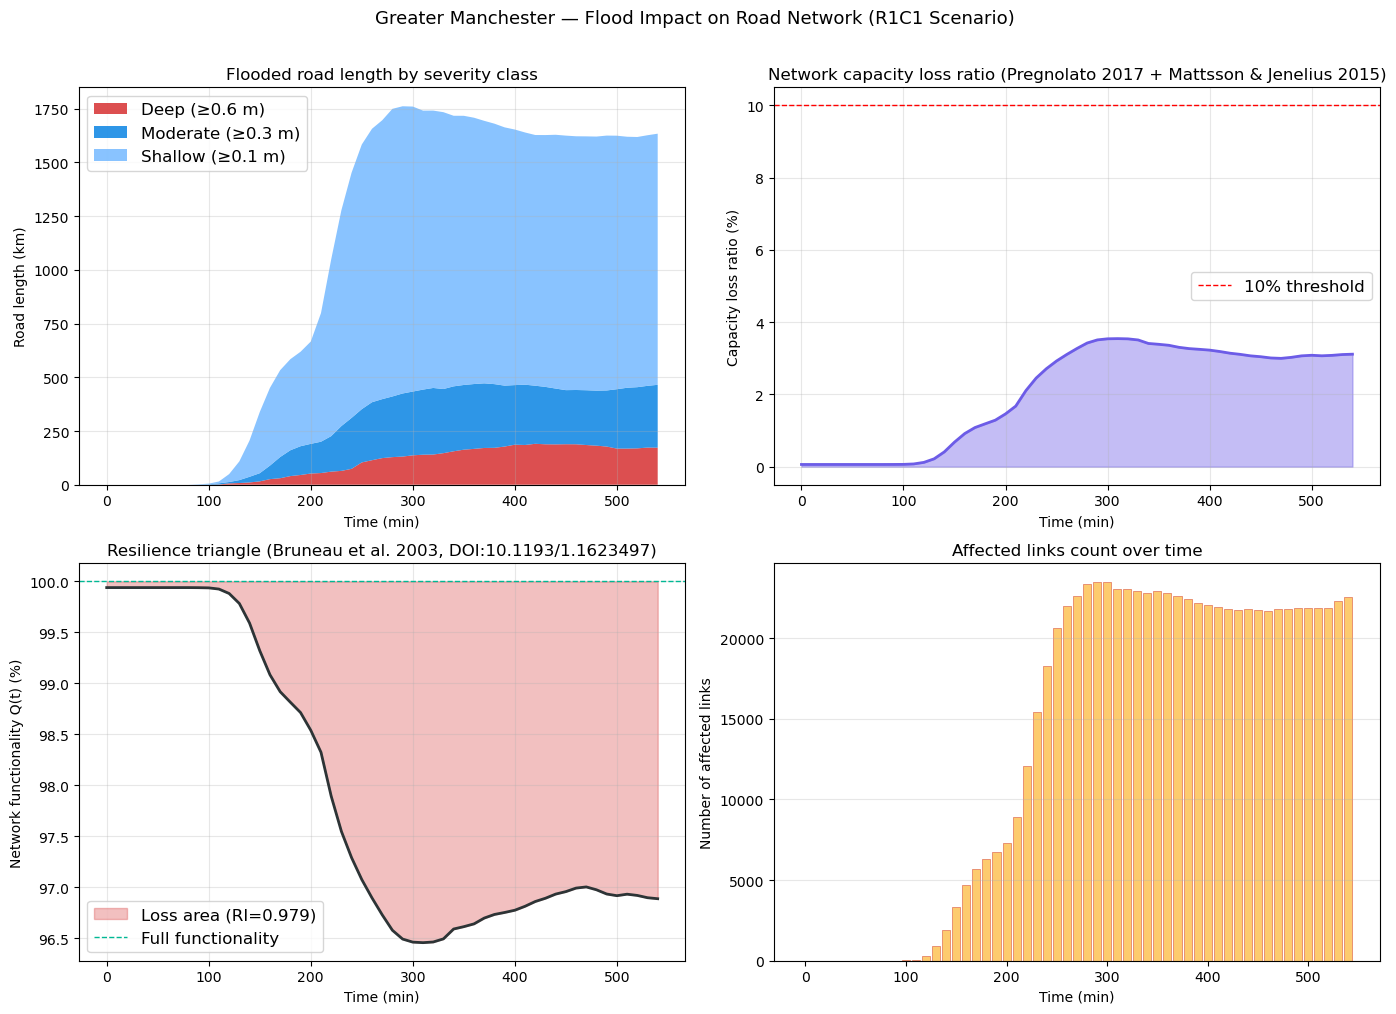

Saved: flood_network_metrics.png


In [ ]:
# ── Figure 1: Flooded km by severity class over time ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fs=14
ax1 = axes[0, 0]
ax1.stackplot(
    metrics.index,
    metrics["km_deep"], metrics["km_moderate"], metrics["km_shallow"],
    labels=["Deep (≥0.6 m)", "Moderate (≥0.3 m)", "Shallow (≥0.1 m)"],
    colors=["#d63031", "#0984e3", "#74b9ff"], alpha=0.85
)
ax1.set_xlabel("Time (min)"); ax1.set_ylabel("Road length (km)")
ax1.set_title("Flooded road length by severity class", fontsize=fs)
ax1.legend(loc="upper left", fontsize=fs); ax1.grid(alpha=0.3)

# ── Figure 2: Capacity loss ratio ───────────────────────────────────────
ax2 = axes[0, 1]
ax2.fill_between(metrics.index, metrics["capacity_loss_ratio"] * 100,
                 alpha=0.4, color="#6c5ce7")
ax2.plot(metrics.index, metrics["capacity_loss_ratio"] * 100,
         color="#6c5ce7", linewidth=2)
ax2.axhline(10, color="red", linestyle="--", linewidth=1, label="10% threshold")
ax2.set_xlabel("Time (min)"); ax2.set_ylabel("Capacity loss ratio (%)")
ax2.set_title("Network capacity loss ratio (Pregnolato 2017 + Mattsson & Jenelius 2015)", fontsize=fs)
ax2.legend(fontsize=fs); ax2.grid(alpha=0.3)

# ── Figure 3: Resilience triangle ────────────────────────────────────────
ax3 = axes[1, 0]
ax3.fill_between(metrics.index, metrics["functionality_Q"] * 100,
                 100, alpha=0.3, color="#d63031", label=f"Loss area (RI={RI:.3f})")
ax3.plot(metrics.index, metrics["functionality_Q"] * 100,
         color="#2d3436", linewidth=2)
ax3.axhline(100, color="#00b894", linestyle="--", linewidth=1, label="Full functionality")
# ax3.set_ylim(0, 105)
ax3.set_xlabel("Time (min)"); ax3.set_ylabel("Network functionality Q(t) (%)")
ax3.set_title("Resilience triangle (Bruneau et al. 2003, DOI:10.1193/1.1623497)", fontsize=fs)
ax3.legend(fontsize=fs); ax3.grid(alpha=0.3)

# ── Figure 4: Number of affected links ───────────────────────────────────
ax4 = axes[1, 1]
ax4.bar(metrics.index, metrics["n_links_affected"], width=8,
        color="#fdcb6e", edgecolor="#e17055", linewidth=0.5)
ax4.set_xlabel("Time (min)"); ax4.set_ylabel("Number of affected links")
ax4.set_title("Affected links count over time")
ax4.grid(alpha=0.3, axis="y")

plt.suptitle("Greater Manchester — Flood Impact on Road Network (R1C1 Scenario)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("flood_network_metrics.png", dpi=150 * 3)  # high DPI for better text clarity
plt.show()
print("Saved: flood_network_metrics.png")

## 13. Generate MATSim networkChangeEvents.xml

### Logic

For each 10-minute time step, we compare each link's reduced freespeed
(derived from the Pregnolato depth–speed function) against its value at the
previous time step. A `<networkChangeEvent>` is only emitted when the
freespeed *changes* — this keeps the file compact and matches MATSim's
event semantics (a value persists until explicitly overridden).

**Flood-to-simulation time mapping:**
The flood event start time in the MATSim simulation is set by
`FLOOD_START_SECONDS` (default: 06:00:00 = 21 600 s).
Each TIF time step *t* minutes maps to simulation time
`FLOOD_START_SECONDS + t × 60` seconds.

**Restoration:**
At `FLOOD_START_SECONDS + (t_max + 10) × 60` a final block restores every
affected link to its original freespeed, signalling the end of the event.

**Link ID convention:**
Uses the `linkID` column (`<edgeID>out` / `<edgeID>rtn`) — matching the
format observed in the reference `networkChangeEvents.xml`.

In [38]:
from xml.etree.ElementTree import Element, SubElement, ElementTree, indent
from tqdm.notebook import tqdm

# ── Configuration ────────────────────────────────────────────────────────
FLOOD_START_SECONDS = 6 * 3600   # 06:00:00
OUT_XML             = "flood_networkChangeEvents.xml"
IMPASSABLE_SPEED    = 0.0001     # m/s — matches convention in reference file

def seconds_to_hhmmss(sec):
    h = int(sec // 3600)
    m = int((sec % 3600) // 60)
    s = int(sec % 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

# ── Per-link arrays (numpy, aligned to ts_depth.index) ───────────────────
link_ids   = ts_depth.index                          # Series of linkID strings
orig_fs_np = orig_fs.reindex(link_ids).values.astype(np.float32)  # original freespeed

# ── Compute target freespeed for every link × every time step ────────────
# target_fs: rows = time steps, columns = linkIDs  (was wrongly ts_depth.columns)
target_fs = pd.DataFrame(
    np.zeros((len(time_steps), len(link_ids)), dtype=np.float32),
    index=time_steps,
    columns=link_ids,          # ← fix: linkIDs, not time_steps
)

print("Computing reduced freespeeds …")
for t in tqdm(time_steps, desc="Time steps", unit="step", ncols=80):
    depths  = ts_depth[t].values.astype(np.float32)      # (n_links,) numpy array
    reduced = pregnolato_speed_ms(depths)                 # vectorised — no .apply()
    reduced = np.minimum(reduced, orig_fs_np)             # cap at original speed
    reduced[depths >= DEPTH_DEEP] = IMPASSABLE_SPEED      # impassable threshold
    target_fs.loc[t] = reduced

# ── Build change events: emit only when freespeed changes ────────────────
prev_fs_np = orig_fs_np.copy()
events = []   # (sim_time_sec, speed_value, [linkID, ...])

for t in time_steps:
    sim_sec    = FLOOD_START_SECONDS + t * 60
    cur_fs_np  = target_fs.loc[t].values.astype(np.float32)
    changed_mask = ~np.isclose(cur_fs_np, prev_fs_np, atol=1e-4)

    if changed_mask.any():
        changed_ids    = link_ids[changed_mask]
        changed_speeds = cur_fs_np[changed_mask]
        # One XML block per unique speed value
        unique_speeds = np.unique(changed_speeds)
        for spd in unique_speeds:
            ids = changed_ids[changed_speeds == spd].tolist()
            events.append((sim_sec, float(spd), ids))

    prev_fs_np = cur_fs_np.copy()

# Restoration block at t_max + 10 min
restore_sec    = FLOOD_START_SECONDS + (time_steps[-1] + 10) * 60
ever_flooded   = (ts_depth.values > DEPTH_SHALLOW).any(axis=1)   # bool array
restore_ids    = link_ids[ever_flooded]
restore_speeds = orig_fs_np[ever_flooded]
for spd in np.unique(restore_speeds):
    ids = restore_ids[restore_speeds == spd].tolist()
    events.append((restore_sec, float(spd), ids))

print(f"Change event blocks : {len(events):,}")
print(f"Links to restore    : {ever_flooded.sum():,}")


Computing reduced freespeeds …


Time steps:   0%|                                      | 0/55 [00:00<?, ?step/s]

Change event blocks : 18,205
Links to restore    : 32,979


In [39]:
# ── Write XML ────────────────────────────────────────────────────────────
root = Element("networkChangeEvents")
root.set("xmlns",     "http://www.matsim.org/files/dtd")
root.set("xmlns:xsi", "http://www.w3.org/2001/XMLSchema-instance")
root.set("xsi:schemaLocation",
         "http://www.matsim.org/files/dtd "
         "http://www.matsim.org/files/dtd/networkChangeEvents.xsd")

for (sim_sec, speed_val, link_ids) in sorted(events, key=lambda x: x[0]):
    evt = SubElement(root, "networkChangeEvent")
    evt.set("startTime", seconds_to_hhmmss(sim_sec))
    for lid in link_ids:
        lnk = SubElement(evt, "link")
        lnk.set("refId", str(lid))
    fs = SubElement(evt, "freespeed")
    fs.set("type", "absolute")
    fs.set("value", f"{speed_val:.10g}")

tree = ElementTree(root)
indent(tree.getroot(), space="  ")   # Python 3.9+
tree.write(OUT_XML, xml_declaration=True, encoding="UTF-8")

print(f"Written: {OUT_XML}")
print(f"  Change event blocks: {len(root):,}")
print(f"  Flood start time:    {seconds_to_hhmmss(FLOOD_START_SECONDS)}")
print(f"  Restoration time:    {seconds_to_hhmmss(restore_sec)}")

Written: flood_networkChangeEvents.xml
  Change event blocks: 18,205
  Flood start time:    06:00:00
  Restoration time:    15:10:00
